In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/urban_analytics.db")
df = pd.read_sql("SELECT * FROM permits_clean", con=engine)

df["issue_date"] = pd.to_datetime(df["issue_date"], errors="coerce")
df["application_start_date"] = pd.to_datetime(df["application_start_date"], errors="coerce")
df["year"] = df["issue_date"].dt.year
df["month"] = df["issue_date"].dt.month
df["month_name"] = df["issue_date"].dt.strftime("%b")
df["year_month"] = df["issue_date"].dt.to_period("M")
df["days_to_issue"] = (df["issue_date"] - df["application_start_date"]).dt.days

print(df.shape)
df.head()

(819820, 30)


,id,permit_num,permit_status,permit_milestone,permit_type,review_type,application_start_date,issue_date,processing_time,street_number,...,census_tract,ward,latitude,longitude,location,year,month,month_name,year_month,days_to_issue
0,1674612,100109616,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,2006-04-26,2006-04-26,0,835.0,...,NaN,NaN,41.897741,-87.623961,POINT (-87.623961315982 41.897740856253),2006,4,Apr,2006-04,0.0
1,1688922,100118245,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,2006-06-13,2006-06-13,0,2140.0,...,NaN,NaN,41.903229,-87.681340,POINT (-87.681339760936 41.903229293025),2006,6,Jun,2006-06,0.0
2,3390256,101058506,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,2024-08-26,2024-10-29,64,1857.0,...,310900.0,25.0,41.859407,-87.673461,POINT (-87.673460709002 41.859406533938),2024,10,Oct,2024-10,64.0
3,3392045,101059488,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,2024-09-09,2024-11-07,59,6054.0,...,30200.0,48.0,41.992505,-87.660492,POINT (-87.660491962918 41.992505368507),2024,11,Nov,2024-11,59.0
4,1610340,100070717,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,2005-10-03,2006-01-27,116,1.0,...,NaN,NaN,41.881816,-87.647215,POINT (-87.647214717041 41.881815631642),2006,1,Jan,2006-01,116.0


In [2]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

id                                   str
permit_num                           str
permit_status                        str
permit_milestone                     str
permit_type                          str
review_type                          str
application_start_date    datetime64[us]
issue_date                datetime64[us]
processing_time                      str
street_number                    float64
street_direction                     str
street_name                          str
work_type                            str
work_description                     str
building_fee_paid                float64
zoning_fee_paid                  float64
other_fee_paid                   float64
total_fee                        float64
reported_cost                    float64
community_area                   float64
census_tract                     float64
ward                             float64
latitude                         float64
longitude                        float64
location        

In [3]:
df = df[(df["year"] >= 2018) & (df["year"] <= 2023)].copy()
df = df[df["total_fee"] <= df["total_fee"].quantile(0.99)].copy()
print(f"Working dataset: {len(df):,} rows")

Working dataset: 238,540 rows


In [4]:
print(df["permit_type"].value_counts())

permit_type
PERMIT – EXPRESS PERMIT PROGRAM    77472
PERMIT - EASY PERMIT PROCESS       72528
PERMIT - RENOVATION/ALTERATION     46562
PERMIT - SIGNS                     17232
PERMIT - ELEVATOR EQUIPMENT         7986
PERMIT - NEW CONSTRUCTION           7825
PERMIT - WRECKING/DEMOLITION        5227
PERMIT - SCAFFOLDING                2217
PERMIT - REINSTATE REVOKED PMT      1491
Name: count, dtype: int64


In [5]:
df.groupby("year").agg(
    total_permits=("id", "count"),
    avg_fee=("total_fee", "mean"),
    avg_days=("days_to_issue", "mean")
).round(2)

,total_permits,avg_fee,avg_days
year,,,
2018,45620,594.77,17.93
2019,47183,576.21,19.39
2020,37419,565.59,21.19
2021,38012,585.11,21.93
2022,37154,644.19,20.53
2023,33152,629.24,25.90


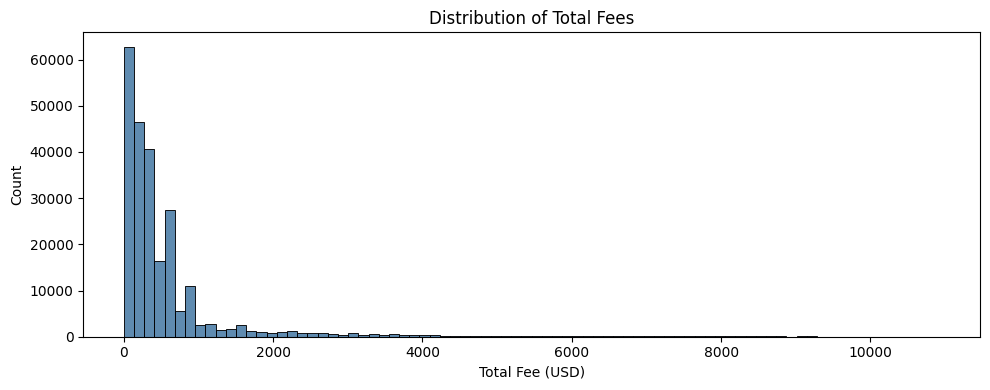

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["total_fee"], bins=80, ax=ax, color="#2a6496")
ax.set_title("Distribution of Total Fees")
ax.set_xlabel("Total Fee (USD)")
plt.tight_layout()
plt.show()